#**Time-Series Forecasting | Corporación Favorita Grocery Sales**

###**Data Preparation**

The original`train.csv` used in this project is a preprocessed subset of a much larger dataset (~5GB). Prior to this notebook, the data was filtered to include only stores from the **Guayas region**, limited to the **top three product families** (Grocery I, Beverages, and Cleaning), and sampled to approximately 300,000 rows to ensure computational efficiency.

In this notebook, the focus is on exploratory data analysis and preprocessing of the provided train.csv, which contains the target variable (unit_sales). Additional datasets (oil prices, holidays, stores, and transactions) are explored separately and later incorporated as exogenous regressors after the primary daily sales time series is aggregated and stabilized.

##**0) Objective**

**Objectives**

- Load all project datasets and validate the sampling filters (Guayas + Top 3 families + ~300k rows).
- Clean key issues (date types, returns/negative sales, missing promotion flags, missing oil values).
- Aggregate to a continuous daily total sales time series required by ARIMA/Prophet baselines.
- Perform EDA to identify trend, weekly seasonality, yearly seasonality, outliers, and external factor signal (oil).

##**1) Setup & Imports**

In [1]:
# Core
import os
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Time handling
from datetime import datetime

pd.set_option("display.max_columns", 100)
sns.set(style="whitegrid")

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


##**2) Load Data (Drive paths)**

In [2]:
DATA_DIR = "/content/drive/MyDrive/TimeSeries"

print("Files in DATA_DIR:")
print(os.listdir(DATA_DIR))

train = pd.read_csv(f"{DATA_DIR}/train.csv")
holidays = pd.read_csv(f"{DATA_DIR}/holidays_events.csv")
items = pd.read_csv(f"{DATA_DIR}/items.csv")
oil = pd.read_csv(f"{DATA_DIR}/oil.csv")
stores = pd.read_csv(f"{DATA_DIR}/stores.csv")
transactions = pd.read_csv(f"{DATA_DIR}/transactions.csv")

Files in DATA_DIR:
['holidays_events.csv', 'oil.csv', 'items.csv', 'stores.csv', 'transactions.csv', 'train.csv', 'largetrain.csv', 'cleaned_sales_data.csv']


In [3]:
# Quick integrity check (shapes + columns)
datasets = {
    "train": train,
    "holidays": holidays,
    "items": items,
    "oil": oil,
    "stores": stores,
    "transactions": transactions
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

for name, df in datasets.items():
    print(f"\n{name.upper()} columns:")
    print(df.columns.tolist())

train: (300000, 11)
holidays: (350, 6)
items: (4100, 4)
oil: (1218, 2)
stores: (54, 5)
transactions: (83488, 3)

TRAIN columns:
['store_nbr', 'item_nbr', 'date', 'id', 'unit_sales', 'onpromotion', 'year', 'month', 'day', 'day_of_week', 'unit_sales_7d_avg']

HOLIDAYS columns:
['date', 'type', 'locale', 'locale_name', 'description', 'transferred']

ITEMS columns:
['item_nbr', 'family', 'class', 'perishable']

OIL columns:
['date', 'dcoilwtico']

STORES columns:
['store_nbr', 'city', 'state', 'type', 'cluster']

TRANSACTIONS columns:
['date', 'store_nbr', 'transactions']


##**3) Initial Inspection (head + info)**

In [4]:
for name, df in datasets.items():
    print(f"\n{name.upper()} preview:")
    display(df.head())
    print(df.info())


TRAIN preview:


,store_nbr,item_nbr,date,id,unit_sales,onpromotion,year,month,day,day_of_week,unit_sales_7d_avg
0,34,165704,2015-11-04,61162432.0,1.0,False,2015,11,4,2,5.714286
1,34,938566,2016-10-14,93853940.0,15.0,False,2016,10,14,4,19.714286
2,35,1159415,2015-06-23,49691210.0,10.0,False,2015,6,23,1,6.285714
3,32,168931,2015-03-22,43369242.0,1.0,False,2015,3,22,6,1.714286
4,36,1919933,2016-07-15,85079911.0,2.0,False,2016,7,15,4,10.142857


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   store_nbr          300000 non-null  int64  
 1   item_nbr           300000 non-null  int64  
 2   date               300000 non-null  object 
 3   id                 300000 non-null  float64
 4   unit_sales         300000 non-null  float64
 5   onpromotion        300000 non-null  bool   
 6   year               300000 non-null  int64  
 7   month              300000 non-null  int64  
 8   day                300000 non-null  int64  
 9   day_of_week        300000 non-null  int64  
 10  unit_sales_7d_avg  299400 non-null  float64
dtypes: bool(1), float64(3), int64(6), object(1)
memory usage: 23.2+ MB
None

HOLIDAYS preview:


,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         350 non-null    object
 1   type         350 non-null    object
 2   locale       350 non-null    object
 3   locale_name  350 non-null    object
 4   description  350 non-null    object
 5   transferred  350 non-null    bool  
dtypes: bool(1), object(5)
memory usage: 14.1+ KB
None

ITEMS preview:


...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1218 non-null   object 
 1   dcoilwtico  1175 non-null   float64
dtypes: float64(1), object(1)
memory usage: 19.2+ KB
None

STORES preview:


,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   store_nbr  54 non-null     int64 
 1   city       54 non-null     object
 2   state      54 non-null     object
 3   type       54 non-null     object
 4   cluster    54 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 2.2+ KB
None

TRANSACTIONS preview:


,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83488 entries, 0 to 83487
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          83488 non-null  object
 1   store_nbr     83488 non-null  int64 
 2   transactions  83488 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.9+ MB
None


###**Key Insights:**
- train contains the **target** (unit_sales) and the core time index (date).
- Other tables provide **context** (holidays, oil, store metadata, transactions) to be merged later as exogenous regressors.

##**4) Verify Sampling Filters (Guayas + Top 3 families)**
This step answers: “How do we know the dataset was filtered correctly?”

In [5]:
train_stores = train.merge(stores, on="store_nbr", how="left")
print("Store states in sample:")
display(train_stores["state"].value_counts())

train_items = train.merge(items, on="item_nbr", how="left")
print("Item families in sample:")
display(train_items["family"].value_counts().head(10))

Store states in sample:


,count
state,
Guayas,300000


Item families in sample:


,count
family,
GROCERY I,171057
BEVERAGES,66038
CLEANING,62905


##**5) Date Parsing**

In [6]:
train["date"] = pd.to_datetime(train["date"])
holidays["date"] = pd.to_datetime(holidays["date"])
oil["date"] = pd.to_datetime(oil["date"])
transactions["date"] = pd.to_datetime(transactions["date"])

##**6) Basic stats + missing values**

In [7]:
print("Train info:")
train.info()

print("\nTrain summary stats:")
display(train.describe(include="all"))

Train info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   store_nbr          300000 non-null  int64         
 1   item_nbr           300000 non-null  int64         
 2   date               300000 non-null  datetime64[ns]
 3   id                 300000 non-null  float64       
 4   unit_sales         300000 non-null  float64       
 5   onpromotion        300000 non-null  bool          
 6   year               300000 non-null  int64         
 7   month              300000 non-null  int64         
 8   day                300000 non-null  int64         
 9   day_of_week        300000 non-null  int64         
 10  unit_sales_7d_avg  299400 non-null  float64       
dtypes: bool(1), datetime64[ns](1), float64(3), int64(6)
memory usage: 23.2 MB

Train summary stats:


,store_nbr,item_nbr,date,id,unit_sales,onpromotion,year,month,day,day_of_week,unit_sales_7d_avg
count,300000.000000,3.000000e+05,300000,3.000000e+05,300000.000000,300000,300000.000000,300000.000000,300000.000000,300000.000000,299400.000000
unique,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,286030,NaN,NaN,NaN,NaN,NaN
mean,32.444370,9.024621e+05,2015-08-30 03:15:57.024000,6.152516e+07,6.851231,NaN,2015.177800,6.327260,15.622280,3.055307,6.245573
min,24.000000,9.699500e+04,2013-01-02 00:00:00,1.886100e+04,0.391000,NaN,2013.000000,1.000000,1.000000,0.000000,-3.714286
25%,27.000000,4.210660e+05,2014-08-28 00:00:00,2.979787e+07,2.000000,NaN,2014.000000,3.000000,8.000000,1.000000,1.571429
50%,30.000000,8.860670e+05,2015-11-01 00:00:00,6.086938e+07,3.000000,NaN,2015.000000,6.000000,16.000000,3.000000,3.142857
75%,35.000000,1.209720e+06,2016-10-06 00:00:00,9.308607e+07,7.000000,NaN,2016.000000,9.000000,23.000000,5.000000,6.428571
max,51.000000,2.127114e+06,2017-08-15 00:00:00,1.254915e+08,3828.000000,NaN,2017.000000,12.000000,31.000000,6.000000,4708.285714


###**Key Insights:**

- **Highly Skewed Sales Distribution:**
  The average daily sales per item are approximately 6.8 units, while the maximum reaches 3,828 units, indicating that most products sell in low volumes with occasional extreme demand spikes.


- **No Evidence of Returns:**
  The minimum recorded sales value is positive (0.39), confirming that the dataset does not include negative sales values and does not require cleaning for returned items.


- **Sufficient Time Horizon:**
  The data spans from January 2013 to August 2017, providing approximately 4.5 years of observations, which is adequate for capturing long-term trends and multiple seasonal cycles.


- **Regional Scope Validated:**
  Store numbers range from 24 to 51, confirming that the dataset is correctly restricted to stores within the Guayas region.


- **Precomputed Feature Inconsistency:**
  The unit_sales_7d_avg feature contains negative values, which are not physically meaningful for sales data. As a result, custom aggregation and feature engineering are required to ensure data integrity.

In [8]:
# Missing values summary (all datasets)
for name, df in datasets.items():
    print(f"\n{name.upper()} missing values:")
    display(df.isna().sum())


TRAIN missing values:


,0
store_nbr,0
item_nbr,0
date,0
id,0
unit_sales,0
onpromotion,0
year,0
month,0
day,0
day_of_week,0



HOLIDAYS missing values:


,0
date,0
type,0
locale,0
locale_name,0
description,0
transferred,0



ITEMS missing values:


...

,0
date,0
dcoilwtico,43



STORES missing values:


,0
store_nbr,0
city,0
state,0
type,0
cluster,0



TRANSACTIONS missing values:


,0
date,0
store_nbr,0
transactions,0


##**7) Cleaning key issues**

###**7.1 Promotions: treat missing as “not on promotion”**

In [9]:
train["onpromotion"] = train["onpromotion"].fillna(0)

###**7.2 Returns/negative sales: clip to 0**

In [10]:
train["unit_sales"] = train["unit_sales"].clip(lower=0)

###**7.3 Oil: forward-fill (missing on weekends/holidays)**

In [11]:
oil = oil.sort_values("date")
oil["dcoilwtico"] = oil["dcoilwtico"].ffill()

- Clipping sales prevents impossible negative demand from distorting totals.
- Forward-filling oil preserves the latest known market price for non-trading days (common approach in time series).

##**8) Aggregate for time series modeling (daily total sales)**

In [12]:
daily_sales = (
    train.groupby("date", as_index=False)["unit_sales"]
    .sum()
    .rename(columns={"unit_sales": "total_sales"})
)

display(daily_sales.head())

,date,total_sales
0,2013-01-02,757.0
1,2013-01-03,534.0
2,2013-01-04,673.0
3,2013-01-05,898.0
4,2013-01-06,975.0


- ARIMA/Prophet require one continuous target series.
- Aggregation reduces item-level noise while preserving trend + seasonality signals.  

##**9) Enforce continuous daily index (fix missing days)**

In [13]:
daily_sales = daily_sales.set_index("date").sort_index()

full_range = pd.date_range(
    start=daily_sales.index.min(),
    end=daily_sales.index.max(),
    freq="D"
)

missing_dates = full_range.difference(daily_sales.index)
print("Missing dates:", len(missing_dates))
print(missing_dates)

daily_sales = daily_sales.reindex(full_range)
daily_sales.index.name = "date"

# fill missing sales with 0 (store closures / no records)
daily_sales["total_sales"] = daily_sales["total_sales"].fillna(0)

daily_sales = daily_sales.reset_index()

Missing dates: 7
DatetimeIndex(['2013-12-25', '2014-12-25', '2015-01-01', '2015-12-25',
               '2016-01-01', '2016-12-25', '2017-01-01'],
              dtype='datetime64[ns]', freq=None)


- Missing dates here typically reflect true “no sales recorded” days (e.g., closures like Christmas/New Year).
- Models require a continuous daily time axis; filling missing calendar days with 0 ensures the series is valid for forecasting.

##**10) Merge external regressors (oil + transactions) for EDA readiness**

###**10.1 Merge oil into daily_sales**

In [14]:
daily_sales = daily_sales.merge(
    oil[["date", "dcoilwtico"]],
    on="date",
    how="left"
)

daily_sales["dcoilwtico"] = daily_sales["dcoilwtico"].ffill()

###**10.2 Merge transactions (daily total)**

In [15]:
transactions_daily = (
    transactions.groupby("date", as_index=False)["transactions"].sum()
)

daily_sales = daily_sales.merge(
    transactions_daily,
    on="date",
    how="left"
)

- These merges prepare the dataset for later models that use exogenous regressors and also support relationship checks during EDA.

#**EDA**

##**11) Overall Sales Trend (line plot)**

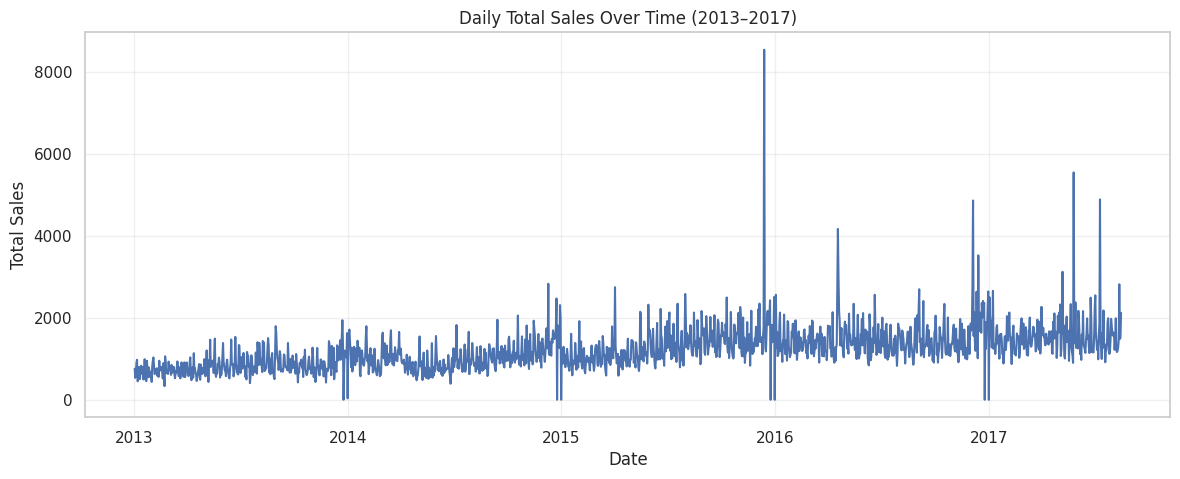

In [16]:
plt.figure(figsize=(14,5))
plt.plot(daily_sales["date"], daily_sales["total_sales"])
plt.title("Daily Total Sales Over Time (2013–2017)")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(alpha=0.3)
plt.show()

**What it shows**

- The overall line direction shows long-term trend (growth/decline).
- Repeating peaks/dips indicate seasonality.
- Single extreme spikes suggest one-time shocks/outliers.

**Key Insights**

- **Trend and Seasonality:**
  The daily sales time series shows a clear upward trend from 2013 to 2017, along with consistent seasonal patterns, particularly during year-end periods.


- **Holiday Effects:**
  Recurrent drops to zero sales at the end of each year correspond to Christmas and New Year's Day store closures. These days are explicitly represented as zero-sales observations after enforcing a continuous daily time index.


- **Extraordinary Events:**
  A pronounced sales spike in April 2016 coincides with the 7.8-magnitude Ecuador earthquake, reflecting atypical demand behavior. This event is treated as an external shock and is captured in the holidays_events dataset.


- **Evolving Seasonal Magnitude:**
  Year-end sales peaks increase over time, particularly from 2015 onward, indicating overall business growth. Despite changing magnitudes, December remains a recurring seasonal period.

##**12) Daily Sales Distribution (histogram)**

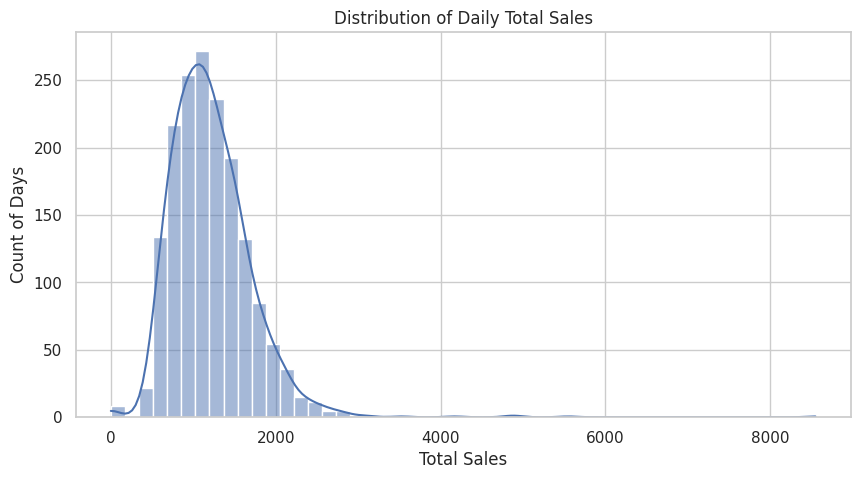

In [17]:
plt.figure(figsize=(10,5))
sns.histplot(daily_sales["total_sales"], bins=50, kde=True)
plt.title("Distribution of Daily Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Count of Days")
plt.show()

**What it shows**

- The height tells you how common a sales level is.
- A long right tail means rare high-sales days.

**Key Insights**

- **Right-Skewed Distribution:**
  Daily total sales exhibit a strong right skew, with most days concentrated at moderate sales levels and a small number of days showing extreme high values.

- **Typical Daily Demand:**
  The mode of the distribution lies approximately between 1,000 and 1,500 units, representing the typical daily sales volume across stores.

- **Zero-Sales Days:**
  Observations near zero confirm the presence of planned store closures on Christmas and New Year's Day, consistent with earlier findings.

- **Impact of Extreme Events:**
  The far-right tail reflects exceptional demand periods, including major holiday peaks and the April 2016 earthquake-related surge observed in the time series plot.

- **Modeling Implications:**
  Since the distribution deviates from normality, variance-stabilizing transformations (e.g., logarithmic transformation) may be considered for models sensitive to distributional assumptions, such as ARIMA.

##**13) Weekly Seasonality (boxplot by weekday)**

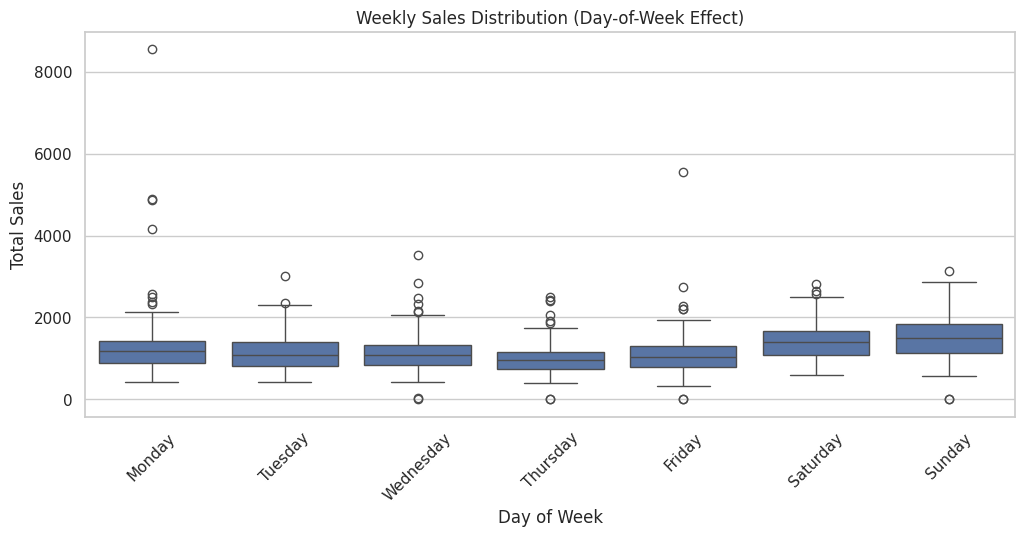

In [18]:
daily_sales["day_of_week"] = daily_sales["date"].dt.day_name()
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

plt.figure(figsize=(12,5))
sns.boxplot(data=daily_sales, x="day_of_week", y="total_sales", order=order)
plt.title("Weekly Sales Distribution (Day-of-Week Effect)")
plt.xlabel("Day of Week")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

**What it shows**

- Middle line of each box = median (typical day).
- Box height = IQR (typical variability).
- Dots beyond whiskers = outliers (unusual days).

**Insights**

- **Weekend Seasonality:**

  Median sales are notably higher on Saturdays and Sundays, confirming consistent and predictable increases in demand during weekends.

- **Exceptional Monday Outlier:**

  The highest single-day sales observation occurs on a Monday, indicating a rare, event-driven anomaly rather than typical weekday demand behavior.

- **Stable Baseline Demand:**

  The interquartile ranges are relatively consistent across weekdays, suggesting that baseline consumer demand remains stable despite the presence of outliers.

- **Holiday Closures Reflected:**

  Observations at or near zero sales across multiple weekdays correspond to known store closures on Christmas and New Year's Day, reinforcing earlier data continuity findings.

##**14) Yearly Seasonality / Growth (boxplot by year)**

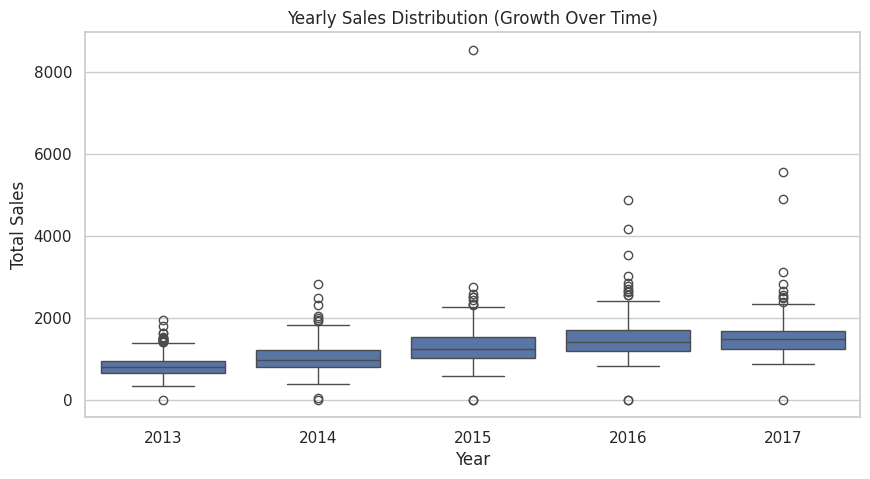

In [19]:
daily_sales["year"] = daily_sales["date"].dt.year

plt.figure(figsize=(10,5))
sns.boxplot(data=daily_sales, x="year", y="total_sales")
plt.title("Yearly Sales Distribution (Growth Over Time)")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.show()

**What it shows**

- If medians rise year to year → baseline demand is increasing.
- Wider boxes later → increasing volatility/scale.

**Insights**

- **Sustained Growth Over Time:**

  Median daily sales increase steadily from 2013 through 2017, indicating consistent long-term business growth.

- **Rising Sales Variability:**

  The interquartile range widens in later years, suggesting that both typical demand and variability increased as the business scaled.

- **Increase in Extreme Demand Events:**

  Higher and more frequent outliers appear from 2015 onward, reflecting stronger holiday peaks and exceptional demand periods.

- **Structural Shift in Demand Levels:**

  The upward shift of the entire distribution over time indicates a fundamental change in baseline demand rather than isolated anomalies.

##**15) External factor check: Oil vs Sales (scatter)**

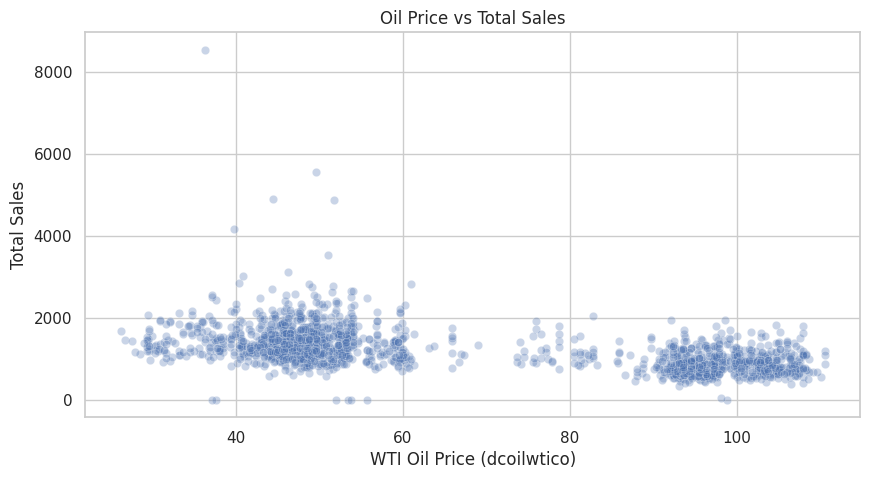

In [20]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=daily_sales, x="dcoilwtico", y="total_sales", alpha=0.3)
plt.title("Oil Price vs Total Sales")
plt.xlabel("WTI Oil Price (dcoilwtico)")
plt.ylabel("Total Sales")
plt.show()

**What it shows**

- A clear upward/downward “slope” would imply correlation.
- A “cloud” with no slope implies weak direct relationship.

**Purpose of Oil Price Analysis (dcoilwtico)**

- dcoilwtico represents the daily WTI crude oil price, an important macroeconomic indicator for Ecuador due to its impact on consumer spending and economic activity.

- This analysis evaluates whether oil prices add explanatory value as an external regressor beyond trend and seasonality in retail sales forecasting models.


**Key Insights**

- **Weak Direct Relationship:**

  The scatter plot does not show a strong linear relationship between oil prices and daily total sales, suggesting oil prices alone do not directly drive short-term retail demand.

- **Regime-Based Clustering:**

  Sales observations appear clustered across different oil price ranges, indicating that demand behavior may differ under broader economic regimes rather than responding proportionally to daily price changes.

- **Presence of Outliers:**

  Extreme sales values occur across multiple oil price levels, implying that exceptional demand events (e.g., holidays, emergencies) dominate daily sales variation more than oil price fluctuations.

- **Potential Complementary Signal:**

  While oil prices are not a primary driver of daily sales, they may still provide contextual value when combined with other features such as holidays, transactions, and seasonal indicators.  

##**16) Oil vs Sales over time (dual-axis)**

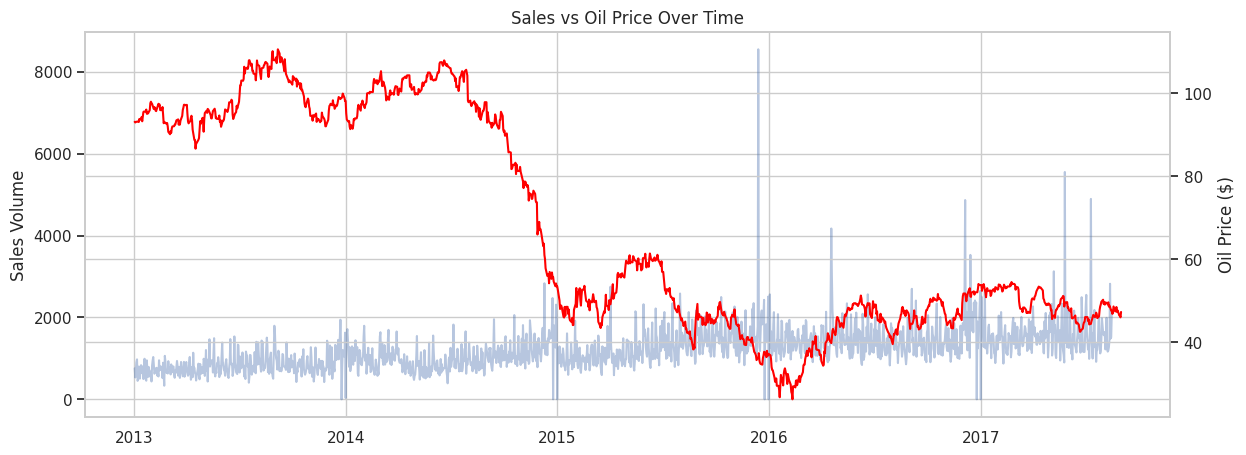

In [21]:
fig, ax1 = plt.subplots(figsize=(14,5))

ax1.plot(daily_sales["date"], daily_sales["total_sales"], alpha=0.4, label="Sales")
ax1.set_ylabel("Sales Volume")

ax2 = ax1.twinx()
ax2.plot(oil["date"], oil["dcoilwtico"], color="red", linewidth=1.5, label="Oil Price")
ax2.set_ylabel("Oil Price ($)")

plt.title("Sales vs Oil Price Over Time")
plt.show()

**Key Insights**

- This checks whether both series shift together across time (co-movement).
- Even if daily correlation is weak, oil may provide broader regime context.

#**Final Output**

##**17) Save prepared dataset**

In [22]:
out_path = f"{DATA_DIR}/cleaned_sales_data.csv"
daily_sales.to_csv(out_path, index=False)
print("Saved to:", out_path)

Saved to: /content/drive/MyDrive/TimeSeries/cleaned_sales_data.csv


#**SUMMARY**

This notebook focuses on data preparation and exploratory data analysis for the retail sales forecasting project. All six datasets were loaded, inspected, and cleaned, with particular attention to data types, missing values, and date consistency. Sales data was aggregated to daily total sales to create a single continuous time series suitable for classical forecasting models such as ARIMA, Exponential Smoothing, and Prophet.

Key data issues, including missing oil prices, promotional indicators, negative sales values, and missing calendar days, were addressed using appropriate and justified techniques. External data sources such as oil prices and transaction counts were integrated to support later modeling as potential regressors.

Exploratory analysis revealed clear long-term trends, strong weekly and yearly seasonality, and increased variability around holiday periods. The resulting cleaned and structured dataset provides a reliable foundation for subsequent time series modeling and evaluation.